In [4]:
import pandas as pd
import numpy as np
from glob import glob

datasets = glob("./data/buenos-aires-real-estate-*.csv")
datasets

['./data/buenos-aires-real-estate-1.csv',
 './data/buenos-aires-real-estate-2.csv',
 './data/buenos-aires-real-estate-3.csv',
 './data/buenos-aires-real-estate-4.csv',
 './data/buenos-aires-real-estate-5.csv']

In [9]:
files = []

for x in datasets:
    data = pd.read_csv(x)
    files.append(data)

len(files)

5

In [10]:
df = pd.concat(files, ignore_index=True)
df.head()

,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
0,sell,apartment,|Argentina|Capital Federal|Villa Crespo|,"-34.6047834183,-58.4586812499",180000.0,USD,2729232.0,180000.0,120.0,110.0,1500.000000,1636.363636,NaN,4.0,NaN,http://villa-crespo.properati.com.ar/12egq_ven...
1,sell,house,|Argentina|Bs.As. G.B.A. Zona Oeste|La Matanza...,NaN,250000.0,USD,3790600.0,250000.0,117.0,120.0,2136.752137,2083.333333,NaN,4.0,NaN,http://ramos-mejia.properati.com.ar/s7pd_venta...
2,sell,house,|Argentina|Bs.As. G.B.A. Zona Oeste|Morón|Cast...,"-34.6497002,-58.658073",410000.0,USD,6216584.0,410000.0,410.0,220.0,1000.000000,1863.636364,NaN,NaN,NaN,http://castelar-moron.properati.com.ar/11vgn_v...
3,sell,house,|Argentina|Bs.As. G.B.A. Zona Oeste|Tres de Fe...,"-34.5957086,-58.5669503",180000.0,USD,2729232.0,180000.0,200.0,135.0,900.000000,1333.333333,NaN,5.0,NaN,http://tres-de-febrero.properati.com.ar/7f7u_v...
4,sell,apartment,|Argentina|Capital Federal|Chacarita|,"-34.5846508988,-58.4546932614",129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...


In [11]:
def merged_files(data):
    """Merge multiple CSV files matching a pattern into a single DataFrame."""
    return pd.concat([pd.read_csv(file) for file in glob(data)], ignore_index=True)

# Usage
merged_files("./data/buenos-aires-real-estate-*.csv").info()

<class 'pandas.DataFrame'>
RangeIndex: 43029 entries, 0 to 43028
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   43029 non-null  str    
 1   property_type               43029 non-null  str    
 2   place_with_parent_names     43029 non-null  str    
 3   lat-lon                     34734 non-null  str    
 4   price                       38073 non-null  float64
 5   currency                    38072 non-null  str    
 6   price_aprox_local_currency  38073 non-null  float64
 7   price_aprox_usd             38073 non-null  float64
 8   surface_total_in_m2         29871 non-null  float64
 9   surface_covered_in_m2       36420 non-null  float64
 10  price_usd_per_m2            24449 non-null  float64
 11  price_per_m2                32642 non-null  float64
 12  floor                       6505 non-null   float64
 13  rooms                       23806 non-null

In [12]:
(
    df
    .loc[lambda x: x["place_with_parent_names"].str.contains("Capital Federal")]
    .query('property_type == "apartment"')
    .query('price_aprox_usd < 400_000')
)

,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
0,sell,apartment,|Argentina|Capital Federal|Villa Crespo|,"-34.6047834183,-58.4586812499",180000.0,USD,2729232.00,180000.0,120.0,110.0,1500.000000,1636.363636,NaN,4.0,NaN,http://villa-crespo.properati.com.ar/12egq_ven...
4,sell,apartment,|Argentina|Capital Federal|Chacarita|,"-34.5846508988,-58.4546932614",129000.0,USD,1955949.60,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...
9,sell,apartment,|Argentina|Capital Federal|Villa Luro|,"-34.6389789,-58.500115",87000.0,USD,1319128.80,87000.0,48.0,42.0,1812.500000,2071.428571,NaN,NaN,NaN,http://villa-luro.properati.com.ar/12m82_venta...
11,sell,apartment,|Argentina|Capital Federal|Once|,"-34.6050060697,-58.4001162302",60000.0,USD,909744.00,60000.0,28.0,28.0,2142.857143,2142.857143,NaN,1.0,NaN,http://once.properati.com.ar/zz0q_venta_depart...
20,sell,apartment,|Argentina|Capital Federal|San Nicolás|,"-34.603898,-58.378617",69000.0,USD,1046205.60,69000.0,NaN,22.0,NaN,3136.363636,23.0,2.0,NaN,http://san-nicolas.properati.com.ar/rnju_venta...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42990,sell,apartment,|Argentina|Capital Federal|Liniers|,"-34.6395276,-58.5196662",290000.0,USD,4397096.00,290000.0,93.0,83.0,3118.279570,3493.975904,NaN,4.0,NaN,http://liniers.properati.com.ar/t11h_venta_dep...
42997,sell,apartment,|Argentina|Capital Federal|Palermo|,"-34.5978249,-58.4164389",150000.0,USD,2274360.00,150000.0,92.0,45.0,1630.434783,3333.333333,NaN,1.0,1000.0,http://palermo.properati.com.ar/zowv_venta_dep...
43001,sell,apartment,|Argentina|Capital Federal|Mataderos|,"-34.6522327,-58.4907391",65000.0,USD,985556.00,65000.0,42.0,42.0,1547.619048,1547.619048,NaN,2.0,1000.0,http://mataderos.properati.com.ar/11zcp_venta_...
43002,sell,apartment,|Argentina|Capital Federal|Mataderos|,"-34.648761,-58.50018",91440.0,USD,1386449.85,91440.0,NaN,48.0,NaN,1905.000000,6.0,2.0,NaN,http://mataderos.properati.com.ar/xlo5_venta_d...


In [13]:
def filter_df(data):
    return data[
        (data["operation"]=="sell")&
        (data["place_with_parent_names"].str.contains("Capital Federal",na=False))&
        (data["property_type"]=="apartment")&
        (data["price_aprox_usd"]<400000)
    ]
filter_df(df).head()

,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
0,sell,apartment,|Argentina|Capital Federal|Villa Crespo|,"-34.6047834183,-58.4586812499",180000.0,USD,2729232.0,180000.0,120.0,110.0,1500.000000,1636.363636,NaN,4.0,NaN,http://villa-crespo.properati.com.ar/12egq_ven...
4,sell,apartment,|Argentina|Capital Federal|Chacarita|,"-34.5846508988,-58.4546932614",129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...
9,sell,apartment,|Argentina|Capital Federal|Villa Luro|,"-34.6389789,-58.500115",87000.0,USD,1319128.8,87000.0,48.0,42.0,1812.500000,2071.428571,NaN,NaN,NaN,http://villa-luro.properati.com.ar/12m82_venta...
11,sell,apartment,|Argentina|Capital Federal|Once|,"-34.6050060697,-58.4001162302",60000.0,USD,909744.0,60000.0,28.0,28.0,2142.857143,2142.857143,NaN,1.0,NaN,http://once.properati.com.ar/zz0q_venta_depart...
20,sell,apartment,|Argentina|Capital Federal|San Nicolás|,"-34.603898,-58.378617",69000.0,USD,1046205.6,69000.0,NaN,22.0,NaN,3136.363636,23.0,2.0,NaN,http://san-nicolas.properati.com.ar/rnju_venta...


In [14]:
def outliers_df(data):
    return (
        data
        .loc[lambda x: x["surface_covered_in_m2"].between(x["surface_covered_in_m2"].quantile(0.1), x["surface_covered_in_m2"].quantile(0.9))]
    )

# Test the function
check_outliers = outliers_df(df)
check_outliers.info()

<class 'pandas.DataFrame'>
Index: 29247 entries, 0 to 43028
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   29247 non-null  str    
 1   property_type               29247 non-null  str    
 2   place_with_parent_names     29247 non-null  str    
 3   lat-lon                     23338 non-null  str    
 4   price                       26963 non-null  float64
 5   currency                    26962 non-null  str    
 6   price_aprox_local_currency  26963 non-null  float64
 7   price_aprox_usd             26963 non-null  float64
 8   surface_total_in_m2         22538 non-null  float64
 9   surface_covered_in_m2       29247 non-null  float64
 10  price_usd_per_m2            18931 non-null  float64
 11  price_per_m2                26962 non-null  float64
 12  floor                       5441 non-null   float64
 13  rooms                       18480 non-null  flo

In [15]:
def modify_cols(data):
    return (
        data
        .assign(
            lat=lambda x: x["lat-lon"].str.split(",", expand=True)[0].astype(float),     
            lon=lambda x: x["lat-lon"].str.split(",", expand=True)[1].astype(float),    
            neighborhood=lambda x: x["place_with_parent_names"].str.split("|", expand=True)[3]            
        )
    )

check_cols = modify_cols(df)
check_cols.info()

<class 'pandas.DataFrame'>
RangeIndex: 43029 entries, 0 to 43028
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   43029 non-null  str    
 1   property_type               43029 non-null  str    
 2   place_with_parent_names     43029 non-null  str    
 3   lat-lon                     34734 non-null  str    
 4   price                       38073 non-null  float64
 5   currency                    38072 non-null  str    
 6   price_aprox_local_currency  38073 non-null  float64
 7   price_aprox_usd             38073 non-null  float64
 8   surface_total_in_m2         29871 non-null  float64
 9   surface_covered_in_m2       36420 non-null  float64
 10  price_usd_per_m2            24449 non-null  float64
 11  price_per_m2                32642 non-null  float64
 12  floor                       6505 non-null   float64
 13  rooms                       23806 non-null

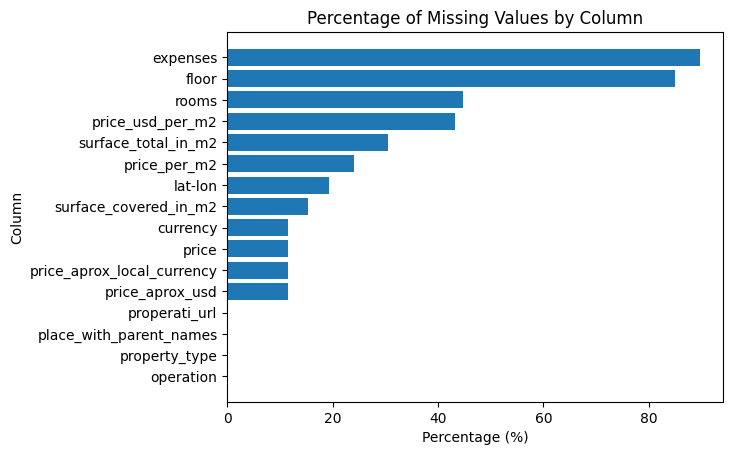

In [16]:
import matplotlib.pyplot as plt

# Percentage of missing values by column
nan_columns_percentage = (df.isna().sum(axis=0) * 100 / len(df)).sort_values()

fig, ax = plt.subplots()

# Horizontal bar plot
ax.barh(y=nan_columns_percentage.index, width=nan_columns_percentage)
ax.set_title('Percentage of Missing Values by Column')
ax.set_xlabel('Percentage (%)')
ax.set_ylabel('Column')
plt.show()

/usr/local/lib/python3.13/site-packages/missingno/missingno.py:61: UserWarning: Plotting a sparkline on an existing axis is not currently supported. To remove this warning, set sparkline=False.
  warnings.warn(


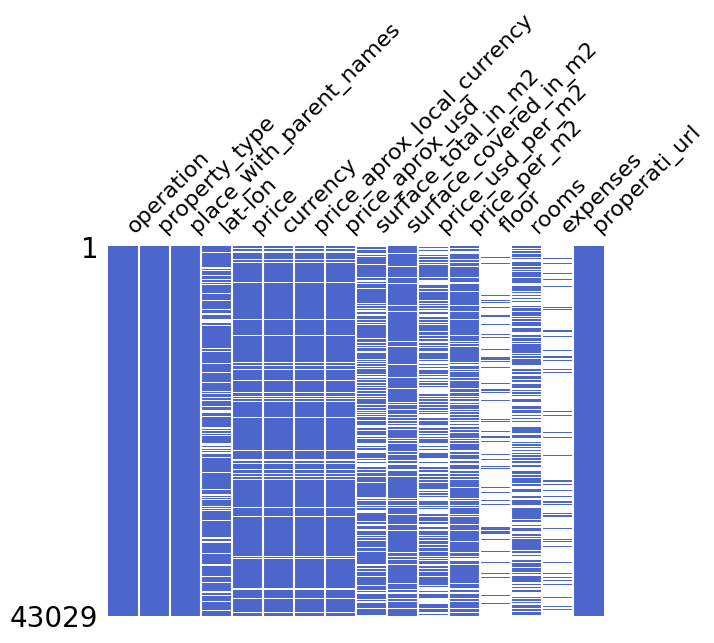

In [17]:
! pip install missingno -q
import missingno as msno

# Plot missing values with color royalblue
fig, ax = plt.subplots()
msno.matrix(df, color=(0.3, 0.4, 0.8), ax=ax)
plt.show()

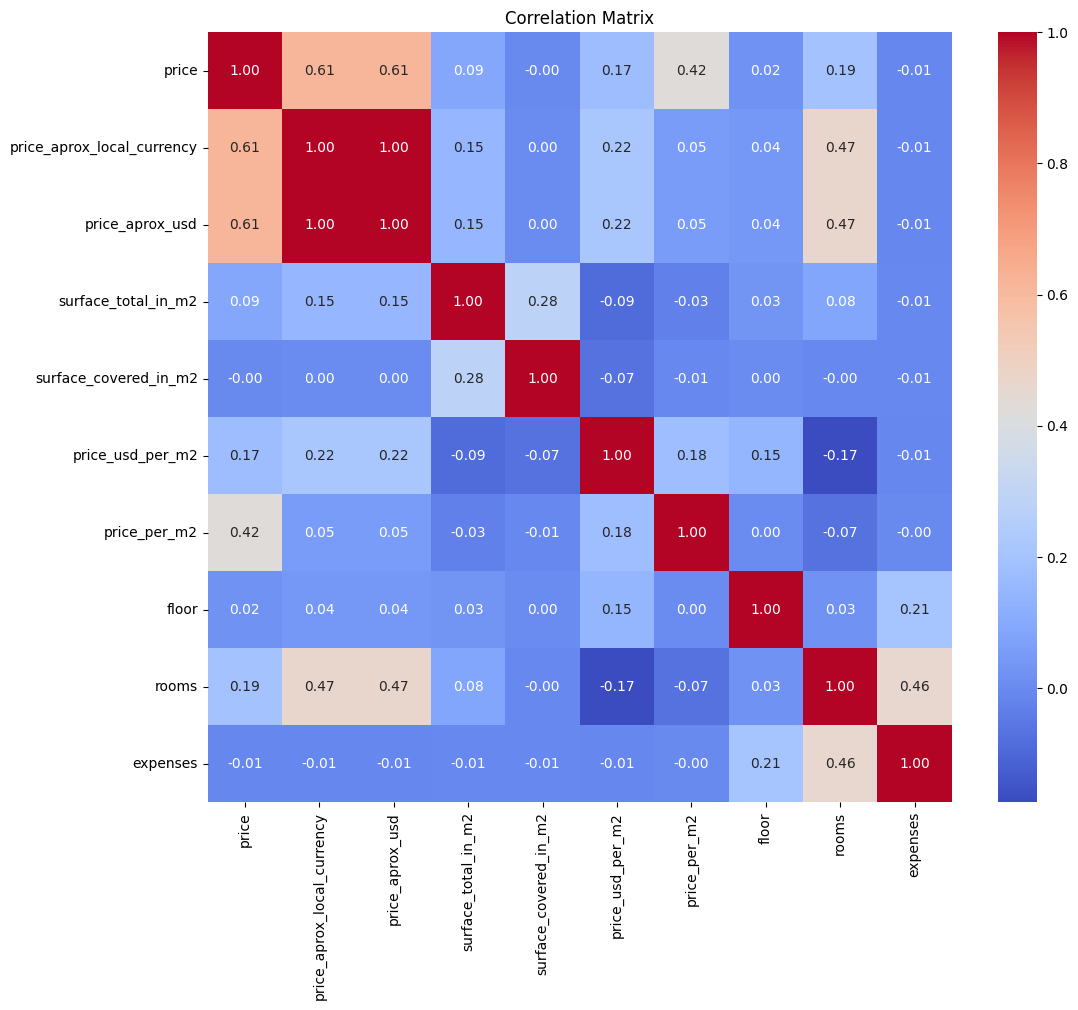

In [18]:
import seaborn as sns

# Calculate correlation matrix for numeric columns
corr_matrix = df.select_dtypes(include='number').corr()  

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Matrix')
plt.show()

In [19]:
drop_cols = [
    "lat-lon", "place_with_parent_names",
    "floor", "expenses", "rooms", "price",
    "price_aprox_local_currency", "price_usd_per_m2",
    "price_per_m2", "operation", "property_type", "currency",
    "properati_url", "surface_total_in_m2"
]

In [20]:
def clean_files(file_path):
    """Final function to complete the cleaning process"""
    drop_cols = [
        "lat-lon", "place_with_parent_names",
        "floor", "expenses", "rooms", "price",
        "price_aprox_local_currency", "price_usd_per_m2",
        "price_per_m2", "operation", "property_type", "currency",
        "properati_url", "surface_total_in_m2"
    ]

    return (
        merged_files(file_path)     
        .pipe(filter_df)            
        .pipe(outliers_df)         
        .pipe(modify_cols)
        .drop(columns=drop_cols)    
        .dropna()                   
    )

clean_df = clean_files("./data/buenos-aires-real-estate-*.csv")
clean_df.info()
clean_df

<class 'pandas.DataFrame'>
Index: 6247 entries, 4 to 43021
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   price_aprox_usd        6247 non-null   float64
 1   surface_covered_in_m2  6247 non-null   float64
 2   lat                    6247 non-null   float64
 3   lon                    6247 non-null   float64
 4   neighborhood           6247 non-null   str    
dtypes: float64(4), str(1)
memory usage: 350.2 KB


,price_aprox_usd,surface_covered_in_m2,lat,lon,neighborhood
4,129000.0,70.0,-34.584651,-58.454693,Chacarita
9,87000.0,42.0,-34.638979,-58.500115,Villa Luro
29,118000.0,54.0,-34.615847,-58.459957,Caballito
40,57000.0,42.0,-34.625222,-58.382382,Constitución
41,90000.0,50.0,-34.610610,-58.412511,Once
...,...,...,...,...,...
42990,290000.0,83.0,-34.639528,-58.519666,Liniers
42997,150000.0,45.0,-34.597825,-58.416439,Palermo
43001,65000.0,42.0,-34.652233,-58.490739,Mataderos
43002,91440.0,48.0,-34.648761,-58.500180,Mataderos


In [21]:
target = "price_aprox_usd"
features = [cols for cols in clean_df.columns if cols not in target]

y = clean_df[target] 
X = clean_df[features]

print(f"y shape: {y.shape}")
print(f"X shape: {X.shape}")

y shape: (6247,)
X shape: (6247, 4)


In [22]:
# Start with cleaned data, select relevant columns, and show first few rows
sample_df = (
    clean_df
    [['neighborhood', 'price_aprox_usd']] 
    .head(5)
)

print("BEFORE One-Hot Encoding:")
print(sample_df)
print(f"\nUnique neighborhoods in sample: {sample_df['neighborhood'].unique()}")

BEFORE One-Hot Encoding:
    neighborhood  price_aprox_usd
4      Chacarita         129000.0
9     Villa Luro          87000.0
29     Caballito         118000.0
40  Constitución          57000.0
41          Once          90000.0

Unique neighborhoods in sample: <ArrowStringArray>
['Chacarita', 'Villa Luro', 'Caballito', 'Constitución', 'Once']
Length: 5, dtype: str


In [28]:
# Transform categorical column into multiple binary columns
encoded_df = (
    sample_df
    .assign(
        is_palermo = sample_df["neighborhood"].apply(lambda x: 1 if x=="Palermo" else 0).astype(int),  # <--- Create binary column: 1 if Palermo, 0 otherwise
        is_caballito = sample_df["neighborhood"].apply(lambda x: 1 if x=="Caballito" else 0).astype(int),  # <--- Create binary column: 1 if Caballito, 0 otherwise
        is_villa_luro = sample_df["neighborhood"].apply(lambda x: 1 if x=="Villa Luro" else 0).astype(int),  # <--- Create binary column: 1 if Villa Luro, 0 otherwise
    )
    .drop(columns=['neighborhood'])
)

print("\nAFTER One-Hot Encoding:")
print(encoded_df)


AFTER One-Hot Encoding:
    price_aprox_usd  is_palermo  is_caballito  is_villa_luro
4          129000.0           0             0              0
9           87000.0           0             0              1
29         118000.0           0             1              0
40          57000.0           0             0              0
41          90000.0           0             0              0


In [29]:
from IPython.display import VimeoVideo

# Bigger video
VimeoVideo("1169844382", h="3298dbabb7", width=700, height=450) 

In [30]:
from sklearn.model_selection import train_test_split

# Split into train and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42  # <--- X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 4997 samples
Test set: 1250 samples


In [31]:
assert 'X_train' in globals(), "❌ You must create a variable named 'X_train'."
assert 'X_test' in globals(), "❌ You must create a variable named 'X_test'."
assert 'y_train' in globals(), "❌ You must create a variable named 'y_train'."
assert 'y_test' in globals(), "❌ You must create a variable named 'y_test'."
assert len(X_train) + len(X_test) == len(X), "❌ Train and test sets don't add up to original size."
assert abs(len(X_test) / len(X) - 0.2) < 0.01, "❌ Test set should be approximately 20% of the data."
assert len(X_train) == len(y_train), "❌ X_train and y_train must have the same length."
assert len(X_test) == len(y_test), "❌ X_test and y_test must have the same length."
print("✅ Train-test split completed successfully!")

✅ Train-test split completed successfully!
